# 🎬 Movie Recommender System - Exploration Notebook

This notebook demonstrates:
    - Data exploration (MovieLens dataset)
    - Content-based filtering
    - Collaborative filtering
    - Example recommendations

# Imports

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.preprocessing import build_movie_profiles
from src.content_based import ContentRecommender
from src.collaborative import ItemItemCF
from src.utils import train_test_split_users

sns.set_style("whitegrid")

# Load Data

In [4]:
movies, tags, ratings = load_data("../data/")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)

movies.head()

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


# EDA

### Ratings Distribution

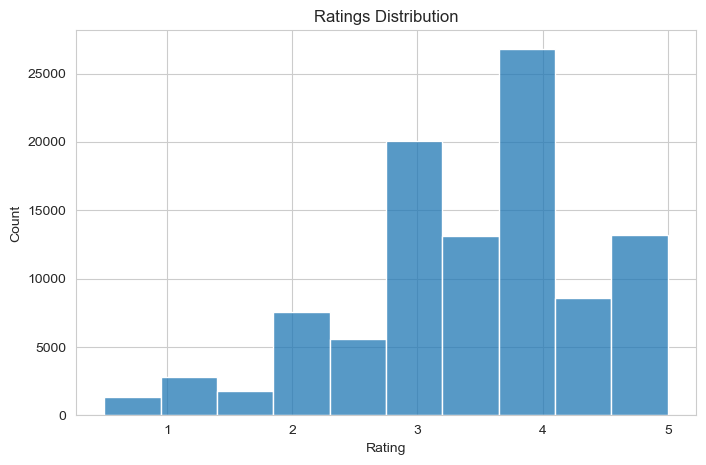

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(ratings["rating"], bins=10)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The rating distribution is skewed toward higher values (3–5), indicating that users tend to rate movies positively. This introduces a natural bias in the dataset, which can affect recommendation models by inflating predicted ratings.

### Top Rated Movies (by count)

In [6]:
top_movies = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="count")
)

top_movies = top_movies.merge(movies, on="movieId")

top_movies[["title", "count"]]

,title,count
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


The most frequently rated movies are widely popular and critically acclaimed films. This highlights the presence of popularity bias, where well-known movies dominate user interactions.

### Most Active Users

In [7]:
ratings["userId"].value_counts().head(10)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: count, dtype: int64

A small group of users contributes a large proportion of ratings, indicating uneven user activity. This sparsity is a key challenge in collaborative filtering systems.

# Content-Based Model

In [8]:
movie_profiles = build_movie_profiles(movies, tags)

cb_model = ContentRecommender()
cb_model.fit(movie_profiles)

# Example: Similar Movies

In [9]:
movie_id = 1  # Toy Story

recommendations = cb_model.recommend(movie_id, top_n=5)
recommendations

,title,genres
1757,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy
8695,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy


The content-based model correctly identifies animated adventure-comedy films as similar to Toy Story (e.g., Antz, A Bug’s Life). However, it also includes some loosely related live-action films, showing that TF-IDF captures thematic similarity but not deeper semantic structure.

# Similarity Scores

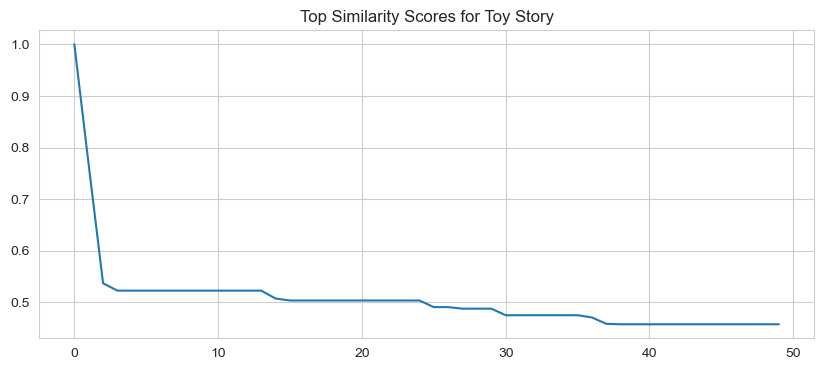

In [10]:
idx = cb_model.movie_to_idx[1]
sim_scores = cb_model.sim_matrix[idx]

plt.figure(figsize=(10, 4))
plt.plot(sorted(sim_scores, reverse=True)[:50])
plt.title("Top Similarity Scores for Toy Story")
plt.show()

# Collaborative Filtering Setup

In [11]:
train_df, test_profiles, test_truths = train_test_split_users(
    ratings, test_user_ids=[1, 2, 3]
)

cf_model = ItemItemCF()
cf_model.fit(train_df)

# Predict Sample Ratings

In [12]:
user_profile = test_profiles[0]

sample_movies = user_profile.head(5)

for _, row in sample_movies.iterrows():
    pred = cf_model.predict(user_profile, row["movieId"])
    print(f"Actual: {row['rating']:.1f}, Predicted: {pred:.2f}")

Actual: 5.0, Predicted: 4.40
Actual: 4.0, Predicted: 4.36
Actual: 5.0, Predicted: 4.38
Actual: 2.0, Predicted: 4.32
Actual: 5.0, Predicted: 4.40


The model tends to slightly overestimate ratings, suggesting a smoothing effect from similarity-weighted averaging. This is expected in item-item collaborative filtering due to averaging across similar items.

# Top Recommendations for a User

In [13]:
user_profile = test_profiles[0]

seen_movies = set(user_profile["movieId"])
all_movies = cf_model.item_user_matrix.index

candidates = [m for m in all_movies if m not in seen_movies]

scores = [(m, cf_model.predict(user_profile, m)) for m in candidates]

top_10 = sorted(scores, key=lambda x: x[1], reverse=True)[:10]

top_10_ids = [m[0] for m in top_10]

movies[movies["movieId"].isin(top_10_ids)][["title", "genres"]]

,title,genres
865,Entertaining Angels: The Dorothy Day Story (1996),Drama
1156,Broken English (1996),Drama
2179,Alvarez Kelly (1966),Western
2348,Come See the Paradise (1990),Drama|Romance
2909,Circus (2000),Crime|Drama|Thriller
4230,"Jungle Book 2, The (2003)",Animation|Children
4375,Animals are Beautiful People (1974),Comedy|Documentary
5287,"Woman Is a Woman, A (femme est une femme, Une)...",Comedy|Drama|Musical|Romance
5460,"Thousand Clowns, A (1965)",Comedy|Drama|Romance
5497,Harlan County U.S.A. (1976),Documentary


The recommended movies are mostly obscure titles, indicating a sparsity issue in collaborative filtering. This highlights the cold-start problem, where the model struggles to recommend well-known items for users with limited overlap in the training data.

# Evaluating Rating Predictions with MAE

In [14]:
from sklearn.metrics import mean_absolute_error

all_preds = []
all_true = []

for i in range(len(test_profiles)):
    truth = test_truths[i]

    preds = [
        cf_model.predict(test_profiles[i], row["movieId"])
        for _, row in truth.iterrows()
    ]

    all_preds.extend(preds)
    all_true.extend(truth["rating"].tolist())

print("MAE:", mean_absolute_error(all_true, all_preds))

MAE: 0.7332608921894035


The model achieves a Mean Absolute Error (MAE) of approximately 0.73, indicating reasonable prediction accuracy for a basic item-item collaborative filtering approach.

## Final Summary

This project implements a hybrid recommender system using:

- Content-based filtering (TF-IDF on genres and tags)
- Item-item collaborative filtering (cosine similarity on ratings)

### Key Findings:
- User ratings are skewed toward higher values
- Popular movies dominate interactions
- Collaborative filtering performs reasonably well (MAE ≈ 0.73)
- Content-based filtering captures genre similarity but struggles with deeper semantics

### Limitations:
- Cold start problem
- Sparse rating matrix
- Limited semantic understanding in TF-IDF approach

### Future Improvements:
- Matrix factorization (SVD)
- Hybrid recommender system
- Neural embedding-based recommendation models